<a href="https://colab.research.google.com/github/mathivathani-1411/mathivathani-codebooster-2026/blob/main/Day9/Day9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install groq -q
print("Libary installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.0 MB/s eta 0:00:00
Libary installed successfully


In [3]:
import sqlite3
import pandas as pd
import os
from groq import Groq
import re
print("All libraries imported successfully")

All libraries imported successfully


In [4]:
import os
os.environ["GROQ_API_KEY"]="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"
client=Groq(api_key=os.environ["GROQ_API_KEY"])
MODEL="llama-3.1-8b-instant"
print("Groq client created successfully")
print(f"Using model:{MODEL}")

Groq client created successfully
Using model:llama-3.1-8b-instant


In [5]:
import io
df=pd.read_csv("student_performance.csv")
print("Datasets loaded successfully")

Datasets loaded successfully


In [6]:
conn=sqlite3.connect("college.db")
df.to_sql("students",conn,if_exists="replace",index=False)
print("Database created:college.db")
print("Table 'students' created with 30 student records")
test_df=pd.read_sql_query("SELECT COUNT(*) as total_rows FROM students",conn)
print(f"\nVerification:{test_df['total_rows'][0]} rows in database")

Database created:college.db
Table 'students' created with 30 student records

Verification:31 rows in database


In [7]:
def get_schema(conn, table_name="students"):
  cursor = conn.cursor()
  cursor.execute(f"PRAGMA table_info({table_name})")
  columns = cursor.fetchall()

  schema_lines = [f"Table: {table_name}"]
  schema_lines.append("Columns:")
  for col in columns:
    schema_lines.append(f"  - {col[1]} ({col[2]})")

  cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")
  sample_rows = cursor.fetchall()
  schema_lines.append("\nSample rows (first 3):")

  for row in sample_rows:
    schema_lines.append(f"  {row}")

  return "\n".join(schema_lines)

schema = get_schema(conn)
print(schema)

Table: students
Columns:
  - student_id (INTEGER)
  - name (TEXT)
  - age (INTEGER)
  - gender (TEXT)
  - department (TEXT)
  - semester (INTEGER)
  - math_score (INTEGER)
  - science_score (INTEGER)
  - english_score (INTEGER)
  - programming_score (INTEGER)
  - attendance_percentage (INTEGER)
  - city (TEXT)
  - admission_year (INTEGER)

Sample rows (first 3):
  (1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)
  (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023)
  (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023)


In [8]:
def generate_sql(user_question, schema_text, client, model):
    """
    this sentence is for you
    """
    system_prompt = f"""You are an expert SQl assistant.
You are connected to a SQLite database with the following structure

{schema_text}

Rules you must follow:
1. Generate ONLY a valid SQLite SQL query.
2. Do not include any explanation or text — only the SQL query.
3. Do not use markdown code blocks. Return the raw SQL only.
4. The table name is: students
5. Only use column names that exist in the schema above.
6. Use single quotes for string values in WHERE clauses (example: WHERE subject = 'Programming').
7. If the user asks for top N, use ORDER BY marks DESC LIMIT N.
"""

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_question},
        ],
        temperature=0.0
    )

    sql_query = response.choices[0].message.content.strip()
    return sql_query


question = "Show me the students name and attendance percentage of the students who have attedance percentage > 85"
print(f"Question: {question}")
print(f"\nGenerating SQL...")

sql = generate_sql(question, schema, client, MODEL)

print(f"\nSQL Generated:\n{sql}")

Question: Show me the students name and attendance percentage of the students who have attedance percentage > 85

Generating SQL...

SQL Generated:
SELECT name, attendance_percentage FROM students WHERE attendance_percentage > 85


In [9]:
def execute_sql(sql_query, conn):
  """
  This is Something
  """

  clean_sql = re.sub(r'```sql\s*','', sql_query)
  clean_sql = clean_sql.strip()

  try:
    result_df = pd.read_sql_query(clean_sql, conn)
    return result_df, None
  except Exception as e:
    return None, str(e)


print(f"Executing SQL:{sql}")
result, error = execute_sql(sql, conn)

if error:
  print(f"Error:{error}")
else:
  print(f"\nQUery returned {len(result)} rows;")
  print(result)

Executing SQL:SELECT name, attendance_percentage FROM students WHERE attendance_percentage > 85

QUery returned 17 rows;
              name  attendance_percentage
0     Aarav Sharma                     92
1      Priya Patel                     87
2      Sneha Reddy                     95
3       Arjun Nair                     90
4      Divya Singh                     96
5       Ananya Das                     98
6       Suresh Rao                     88
7    Kavya Nambiar                     91
8     Ritu Agarwal                     93
9   Swati Kulkarni                     94
10    Nisha Kapoor                     89
11     Tanvi Mehta                     97
12   Preeti Saxena                     86
13       Amit Bose                     91
14   Gaurav Shukla                     87
15  Akanksha Yadav                     95
16  Akanksha Yadav                     95


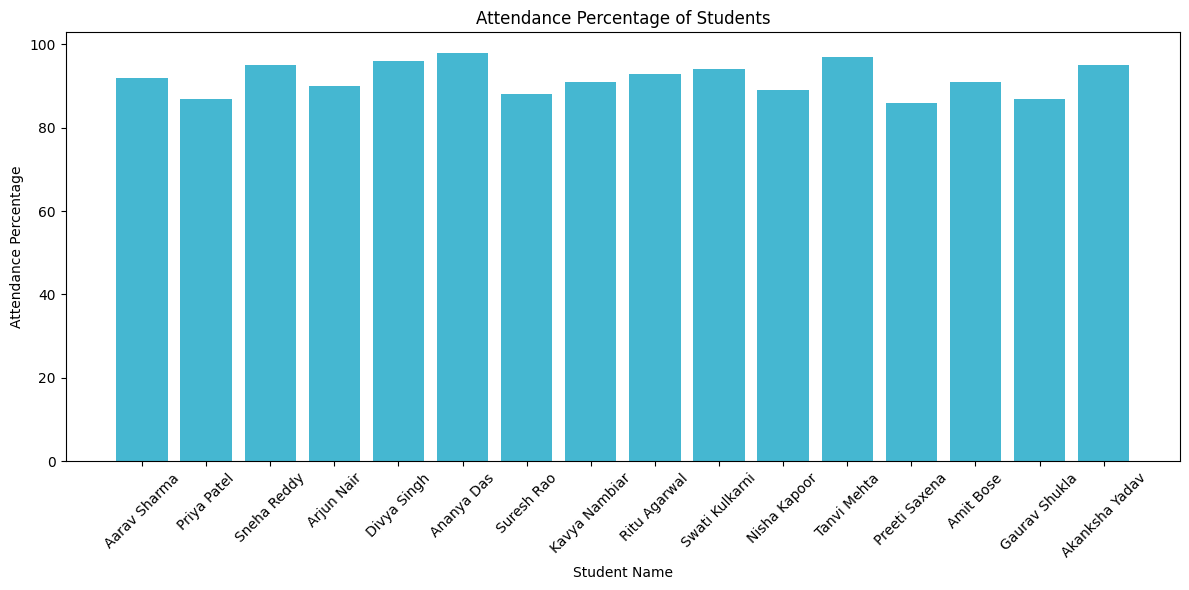

In [10]:
import matplotlib.pyplot as plt

Top5 = result.head(5)
plt.figure(figsize=(12, 6))

plt.bar(
    result['name'],
    result['attendance_percentage'],
    color='#45B7D1'
)

plt.title('Attendance Percentage of Students')
plt.xlabel('Student Name')
plt.ylabel('Attendance Percentage')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [28]:
## the complete Text-to-SQL Agent Function

def def_to_sql_agent(user_question,conn,client,model,verbose=True):
  """ this is main AI function """
  print(f"User question:{user_question}")
  print("="*60)

  #step 1 = verbose get the db schema
  if verbose:
    print("\n[STEP 1] Reading database schema")
  schema_text=get_schema(conn)

  if verbose:
    print("Schema loaded succssfully")

  ##step -2 generate SQL

  if verbose:
    print("\n[STEP 2] Generating SQL query with groq LLM...")

  generated_sql=generate_sql(user_question,schema_text,client,model)


  if verbose:
    print(f'Generated SQL:\n{generated_sql}')


  #STEP 3:EXECUTE SQL ON THE DB

  if verbose:
    print("\n [STEP 3] Executing SQL on db...")

  # Fix: Pass generated_sql string, not the function itself
  result_df,error = execute_sql(generated_sql,conn)


  if error:
    print(f'Error executing SQL:{error}')
    return None,generated_sql

##STEP 4 display the results

  if verbose:
    print(f'\n STEP 4 QUERY RETURNED{len(result_df)} row(s)')
    print("\nRESULTS:")
    print("-"*60)
    print(result_df.to_string(index=False))

  print("="*60)
  return result_df,generated_sql


#test our complete agent

result,sql_used = def_to_sql_agent(
    "Show top 5 students with Programming",
    conn,client,MODEL
)

User question:Show top 5 students with Programming

[STEP 1] Reading database schema
Schema loaded succssfully

[STEP 2] Generating SQL query with groq LLM...
Generated SQL:
SELECT name FROM students WHERE department = 'Computer Science' ORDER BY programming_score DESC LIMIT 5

 [STEP 3] Executing SQL on db...

 STEP 4 QUERY RETURNED5 row(s)

RESULTS:
------------------------------------------------------------
          name
    Ananya Das
   Tanvi Mehta
    Arjun Nair
Akanksha Yadav
Akanksha Yadav
